# Bagging

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import os

In [5]:
os.getcwd()

'C:\\Users\\pmgho'

In [6]:
os.chdir("C:\\Users\\pmgho\\Downloads\\Prajwal Machine Learning Data Set")

In [7]:
os.getcwd()

'C:\\Users\\pmgho\\Downloads\\Prajwal Machine Learning Data Set'

In [8]:
df = pd.read_csv("Iris.csv")

In [9]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [10]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [11]:
df = df.iloc[:,1:]
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [12]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [13]:
from sklearn.preprocessing import LabelEncoder

In [14]:
encoder = LabelEncoder()

In [15]:
df['Species'] = encoder.fit_transform(df['Species'])

In [16]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [17]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [18]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


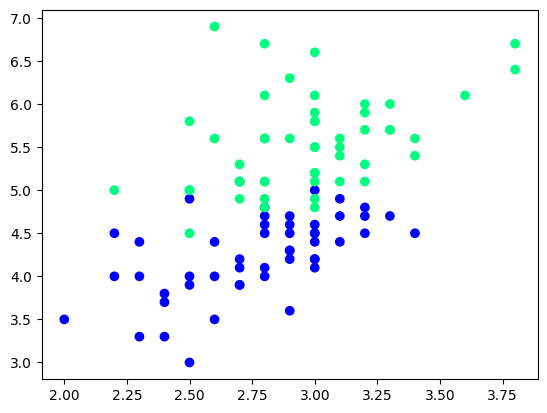

In [20]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [21]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
68,2.2,4.5,1
103,2.9,5.6,2
98,2.5,3.0,1
67,2.7,4.1,1
99,2.8,4.1,1
101,2.7,5.1,2
70,3.2,4.8,1
78,2.9,4.5,1
83,2.7,5.1,1
74,2.9,4.3,1


#### Taking only 10 rows for training

In [22]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [23]:
df_train

,SepalWidthCm,PetalLengthCm,Species
135,3.0,6.1,2
114,2.8,5.1,2
99,2.8,4.1,1
124,3.3,5.7,2
131,3.8,6.4,2
138,3.0,4.8,2
132,2.8,5.6,2
91,3.0,4.6,1
117,3.8,6.7,2
147,3.0,5.2,2


In [24]:
df_val

,SepalWidthCm,PetalLengthCm,Species
149,3.0,5.1,2
142,2.7,5.1,2
81,2.4,3.7,1
74,2.9,4.3,1
51,3.2,4.5,1


In [26]:
df_test

,SepalWidthCm,PetalLengthCm,Species
68,2.2,4.5,1
82,2.7,3.9,1
72,2.5,4.9,1
139,3.1,5.4,2
66,3.0,4.5,1


In [27]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [28]:
y_test

array([2, 2, 1, 1, 1])

In [29]:
X_test

array([[3. , 5.1],
       [2.7, 5.1],
       [2.4, 3.7],
       [2.9, 4.3],
       [3.2, 4.5]])

Case 1 - Bagging

In [30]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
df_bag

,SepalWidthCm,PetalLengthCm,Species
131,3.8,6.4,2
147,3.0,5.2,2
99,2.8,4.1,1
147,3.0,5.2,2
117,3.8,6.7,2
132,2.8,5.6,2
114,2.8,5.1,2
99,2.8,4.1,1


In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [34]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

In [35]:
dt_bag1 = DecisionTreeClassifier()

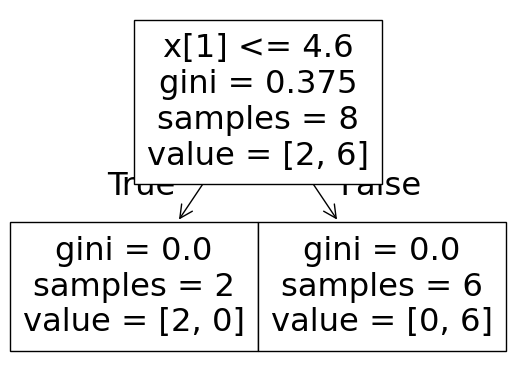

C:\Users\pmgho\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\pmgho\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


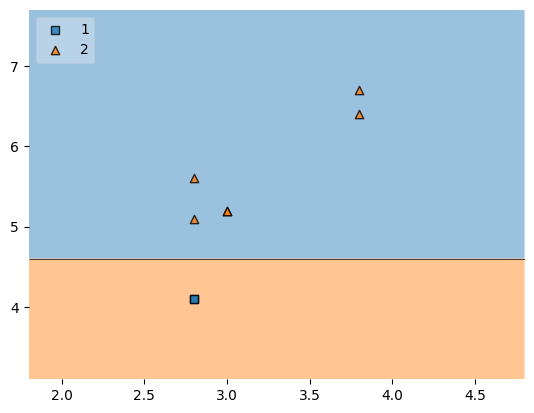

In [36]:
evaluate(dt_bag1,X,y)

In [37]:
# Data for Tree 2
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
131,3.8,6.4,2
135,3.0,6.1,2
124,3.3,5.7,2
114,2.8,5.1,2
99,2.8,4.1,1
124,3.3,5.7,2
138,3.0,4.8,2
138,3.0,4.8,2


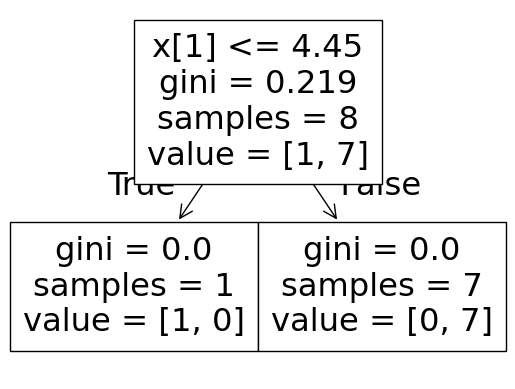

C:\Users\pmgho\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\pmgho\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


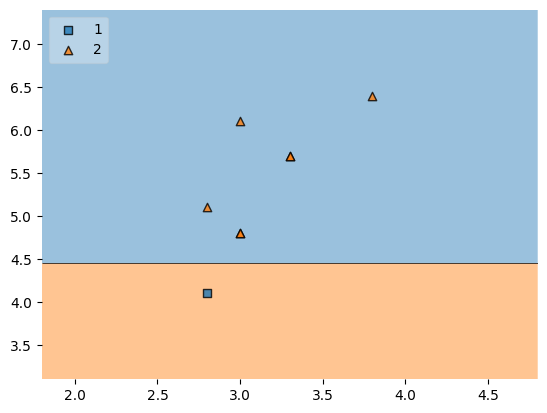

In [41]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [42]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
117,3.8,6.7,2
117,3.8,6.7,2
132,2.8,5.6,2
117,3.8,6.7,2
138,3.0,4.8,2
131,3.8,6.4,2
138,3.0,4.8,2
132,2.8,5.6,2


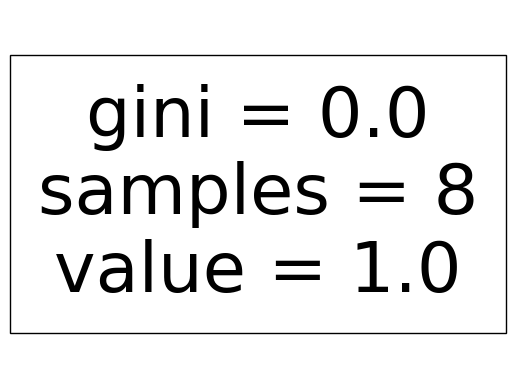

C:\Users\pmgho\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\pmgho\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.4


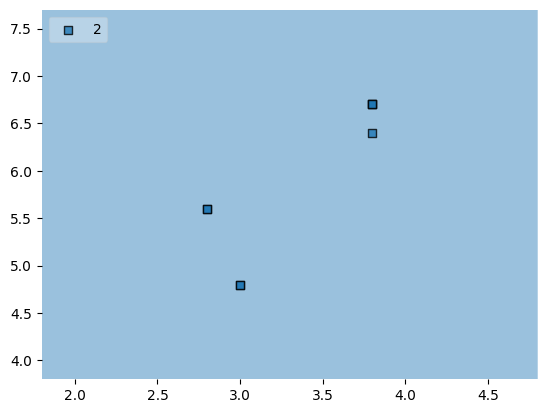

In [43]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

### Predict

In [39]:
df_test

,SepalWidthCm,PetalLengthCm,Species
68,2.2,4.5,1
82,2.7,3.9,1
72,2.5,4.9,1
139,3.1,5.4,2
66,3.0,4.5,1


In [44]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


C:\Users\pmgho\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\pmgho\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\pmgho\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [45]:
print("Predictor 1",dt_bag1.predict(np.array([2.5,4.9]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.5,4.9]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.5,4.9]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


C:\Users\pmgho\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\pmgho\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\pmgho\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


### Pasting

In [46]:
# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
135,3.0,6.1,2
114,2.8,5.1,2
99,2.8,4.1,1
124,3.3,5.7,2
131,3.8,6.4,2
138,3.0,4.8,2
132,2.8,5.6,2
91,3.0,4.6,1
117,3.8,6.7,2
147,3.0,5.2,2


In [47]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
135,3.0,6.1,2
114,2.8,5.1,2
99,2.8,4.1,1
132,2.8,5.6,2
131,3.8,6.4,2
91,3.0,4.6,1
117,3.8,6.7,2
147,3.0,5.2,2


### Random Subspaces

In [48]:
df1 = pd.read_csv("iris.csv")
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [49]:
df1.sample(2,replace=True,axis=1)

,SepalWidthCm,Id
0,3.5,1
1,3.0,2
2,3.2,3
3,3.1,4
4,3.6,5
...,...,...
145,3.0,146
146,2.5,147
147,3.0,148
148,3.4,149


In [50]:
# Random Patches
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [51]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,Species,Id
46,Iris-setosa,47
115,Iris-virginica,116
66,Iris-versicolor,67
146,Iris-virginica,147
47,Iris-setosa,48
71,Iris-versicolor,72
40,Iris-setosa,41
119,Iris-virginica,120
